In [54]:
import numpy as np
import matplotlib.pyplot as plt

def get_direct_neighbors(grid, x, y):
    """Get direct neighbors (north, south, east, west)."""
    neighbors = []
    grid_size = grid.shape[0]
    for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
        nx, ny = x + dx, y + dy
        if 0 <= nx < grid_size and 0 <= ny < grid_size:
            neighbors.append(grid[nx, ny])
    return neighbors

def is_satisfied(grid, x, y, tolerance):
    """Check if agent is satisfied with its neighborhood."""
    agent = grid[x, y]
    if agent == 0:
        return True
    
    neighbors = get_direct_neighbors(grid, x, y)
    if not neighbors:
        return False
    
    same_type = sum(1 for n in neighbors if n == agent)
    return same_type / len(neighbors) >= tolerance

def initialize_grid(grid_size=50, density=0.75):
    """Initialize the grid with agents of type 1 and 2."""
    num_cells = grid_size**2
    num_agents = int(num_cells * density)
    num_agents = (num_agents // 2) * 2  # Ensure even number of agents
    
    # Create balanced array of agents
    agents = np.zeros(num_cells, dtype=np.int8)
    agents[:num_agents//2] = 1
    agents[num_agents//2:num_agents] = 2
    
    # Shuffle and reshape
    np.random.shuffle(agents)
    grid = agents.reshape(grid_size, grid_size)
    
    # Pre-compute empty spots
    empty_spots = set((x, y) for x in range(grid_size) for y in range(grid_size) if grid[x, y] == 0)
    
    return grid, empty_spots

def getRandomAgent(grid, unhappy_agents):
    """Select a random unhappy agent."""
    if not unhappy_agents:
        return None
    return list(unhappy_agents)[np.random.randint(0, len(unhappy_agents))]

def step(agent, grid, tolerance, empty_spots, unhappy_agents):
    """Move an agent to a new location if unhappy."""
    if agent is None:
        return grid, empty_spots, unhappy_agents, False
        
    x, y = agent
    grid_size = grid.shape[0]
    
    # Skip if the agent became happy since being added to the list
    if is_satisfied(grid, x, y, tolerance) or grid[x, y] == 0:
        unhappy_agents.remove(agent)
        return grid, empty_spots, unhappy_agents, False
    
    # Move agent if empty spots exist
    if empty_spots:
        # Select random empty spot
        new_x, new_y = list(empty_spots)[np.random.randint(0, len(empty_spots))]
        
        # Move the agent
        agent_type = grid[x, y]
        grid[new_x, new_y] = agent_type
        grid[x, y] = 0
        
        # Update empty spots
        empty_spots.remove((new_x, new_y))
        empty_spots.add((x, y))
        
        # Remove from unhappy list
        unhappy_agents.remove((x, y))
        
        # Check if agent is happy at new location
        if not is_satisfied(grid, new_x, new_y, tolerance):
            unhappy_agents.add((new_x, new_y))
        
        # Check if neighbors of old location are now unhappy
        for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nx, ny = x + dx, y + dy
            if (0 <= nx < grid_size and 0 <= ny < grid_size and 
                grid[nx, ny] != 0):
                if is_satisfied(grid, nx, ny, tolerance):
                    # Remove from unhappy if it was there
                    unhappy_agents.discard((nx, ny))
                else:
                    # Add to unhappy if not already there
                    unhappy_agents.add((nx, ny))
        
        # Check if neighbors of new location are now unhappy
        for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nx, ny = new_x + dx, new_y + dy
            if (0 <= nx < grid_size and 0 <= ny < grid_size and 
                grid[nx, ny] != 0):
                if is_satisfied(grid, nx, ny, tolerance):
                    # Remove from unhappy if it was there
                    unhappy_agents.discard((nx, ny))
                else:
                    # Add to unhappy if not already there
                    unhappy_agents.add((nx, ny))
        
        return grid, empty_spots, unhappy_agents, True
    
    return grid, empty_spots, unhappy_agents, False

def plot_grid(grid, iteration, cmap):
    """Plot the grid at a given iteration."""
    plt.figure(figsize=(6, 6))
    plt.imshow(grid, cmap=cmap, vmin=0, vmax=2)
    plt.title(f'Iteration: {iteration}')
    plt.show(block=False)
    plt.pause(0.1)
    print(f"Created plot for iteration {iteration}")

def run_schelling_simulation(grid_size=50, density=0.75, tolerance=0.3, max_iterations=10000):
    """Run the Schelling segregation model simulation with initial, 1000th and final plots."""
    # Initialize the grid
    grid, empty_spots = initialize_grid(grid_size, density)
    
    # Set up plotting
    cmap = plt.cm.colors.ListedColormap(['white', 'green', 'blue'])
    
    # Store unhappy agents rather than checking all agents each time
    unhappy_agents = set()
    for x in range(grid_size):
        for y in range(grid_size):
            if grid[x, y] != 0 and not is_satisfied(grid, x, y, tolerance):
                unhappy_agents.add((x, y))
    
    # Plot initial state (iteration 0)
    plot_grid(grid, 0, cmap)
    
    # Main simulation loop
    iteration = 0
    
    while iteration < max_iterations:
        # Get a random unhappy agent
        agent = getRandomAgent(grid, unhappy_agents)
        
        # No more unhappy agents
        if agent is None:
            break
        
        # Perform a step of the simulation
        grid, empty_spots, unhappy_agents, has_moved = step(agent, grid, tolerance, empty_spots, unhappy_agents)
        
        # Only increment iteration counter if an agent actually moved
        if has_moved:
            iteration += 1
            
            # Plot at 1000th iteration
            if iteration == 1000:
                plot_grid(grid, 1000, cmap)
    
    # Print final iteration count and reason for termination
    if iteration >= max_iterations:
        print(f"Reached maximum iteration limit: {max_iterations}")
    elif not unhappy_agents:
        print(f"All agents are satisfied - equilibrium reached at iteration {iteration}")
    
    # Plot final state if it's not the same as the 1000th iteration
    if iteration != 1000:
        plot_grid(grid, iteration, cmap)
    
    # Make sure all plots are shown
    plt.show()
    
    # Return final state
    return grid

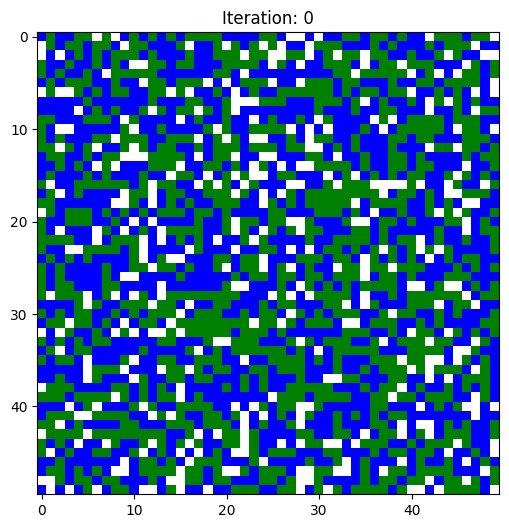

Created plot for iteration 0
All agents are satisfied - equilibrium reached at iteration 283


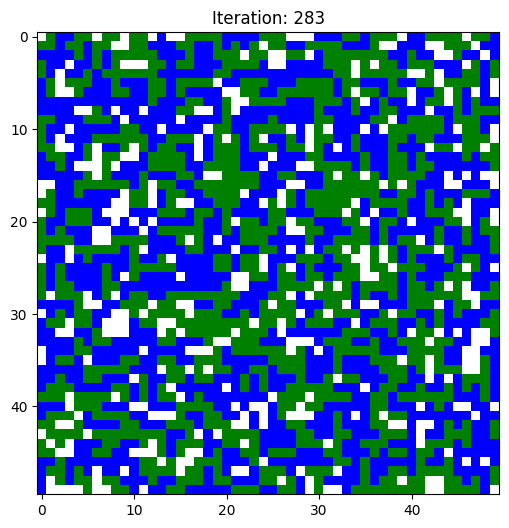

Created plot for iteration 283


array([[0, 1, 2, ..., 1, 1, 2],
       [1, 1, 2, ..., 0, 2, 2],
       [2, 2, 2, ..., 2, 0, 2],
       ...,
       [2, 1, 1, ..., 2, 2, 1],
       [2, 0, 1, ..., 1, 2, 1],
       [2, 0, 0, ..., 1, 2, 0]], dtype=int8)

In [60]:
#run_schelling_simulation(grid_size=50, density=0.85, tolerance=0.3, max_iterations=10000)
run_schelling_simulation(grid_size=50, density=0.85, tolerance=0.25, max_iterations=10000)
#runSchellingSimulation(grid_size=50, density=0.75, tolerance=0.26)
#runSchellingSimulation(grid_size=50, density=0.75, tolerance=0.25)